# Cvičenie: Predikcia platu pomocou neurónovej siete

**Dataset:** `data/job_salary_prediction_dataset.csv`  
**Úloha:** Regresia — predikuj ročný plat na základe pracovných charakteristík  
**Architektúra:** MLP (Multi-Layer Perceptron)  

---

### Postup (workflow)
1. Načítaj a preskúmaj dáta
2. One-Hot Encoding kategorických stĺpcov
3. Rozdeľ dataset na train / val / test
4. Štandardizuj features (fit iba na train!)
5. Vytvor PyTorch DataLoader-y
6. Definuj model
7. Trénuj s early stopping
8. Vyhodnoť na testovacej množine

## 0. Importy

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Zariadenie: {device}")
kagglehub.dataset_download("nalisha/job-salary-prediction-dataset", output_dir="./data")


Zariadenie: cuda


'./data'

## 1. Načítanie a prieskum datasetu

Stĺpce v datasete:
- **Numerické:** `experience_years`, `skills_count`, `certifications`
- **Kategorické:** `job_title`, `education_level`, `industry`, `company_size`, `location`, `remote_work`
- **Target:** `salary` (ročný plat v USD)

In [2]:
df = pd.read_csv("data/job_salary_prediction_dataset.csv")

print(df.shape)
df.head()

(250000, 10)


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [4]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [5]:
print("Chýbajúce hodnoty:")
print(df.isnull().sum())

Chýbajúce hodnoty:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


In [6]:
cat_cols = ["job_title", "education_level", "industry", "company_size", "location", "remote_work"]

# Nápoveda: df[col].nunique() a df[col].unique()
for col in cat_cols:
    print(df[col].nunique(), df[col].unique())

12 <StringArray>
[              'AI Engineer',              'Data Analyst',
        'Frontend Developer',          'Business Analyst',
           'Product Manager',         'Backend Developer',
 'Machine Learning Engineer',           'DevOps Engineer',
         'Software Engineer',     'Cybersecurity Analyst',
            'Data Scientist',            'Cloud Engineer']
Length: 12, dtype: str
5 <StringArray>
['Bachelor', 'PhD', 'High School', 'Diploma', 'Master']
Length: 5, dtype: str
10 <StringArray>
[   'Healthcare',       'Telecom',         'Media',        'Retail',
 'Manufacturing',     'Education',       'Finance',    'Technology',
    'Consulting',    'Government']
Length: 10, dtype: str
5 <StringArray>
['Medium', 'Small', 'Large', 'Enterprise', 'Startup']
Length: 5, dtype: str
10 <StringArray>
[      'India',   'Australia',   'Singapore',      'Canada',      'Sweden',
         'USA', 'Netherlands',      'Remote',     'Germany',          'UK']
Length: 10, dtype: str
3 <StringArray>

## 2. One-Hot Encoding (OHE)

Neurónová sieť pracuje iba s číslami. Kategorické stĺpce musíme zakódovať.

**One-Hot Encoding:** každá kategória dostane vlastný binárny stĺpec (0 alebo 1).  
Príklad pre `remote_work`:
```
remote_work    →   remote_work_Hybrid   remote_work_Yes
"No"                      0                   0
"Hybrid"                  1                   0
"Yes"                     0                   1
```
`drop_first=True` odstráni prvú kategóriu (predchádza multikolinearite).

**Dôležité:** OHE rob na celom DataFrame *pred* rozdelením na train/test,  
aby všetky sety mali rovnaké stĺpce.

In [7]:
num_cols = ["experience_years", "skills_count", "certifications"]
target_col = "salary"

# Výsledok ulož do df_encoded
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Počet stĺpcov pred OHE: {df.shape[1]}")
print(f"Počet stĺpcov po OHE:   {df_encoded.shape[1]}")
print()
print("Stĺpce po OHE:")
print(df_encoded.columns.tolist())

Počet stĺpcov pred OHE: 10
Počet stĺpcov po OHE:   43

Stĺpce po OHE:
['experience_years', 'skills_count', 'certifications', 'salary', 'job_title_Backend Developer', 'job_title_Business Analyst', 'job_title_Cloud Engineer', 'job_title_Cybersecurity Analyst', 'job_title_Data Analyst', 'job_title_Data Scientist', 'job_title_DevOps Engineer', 'job_title_Frontend Developer', 'job_title_Machine Learning Engineer', 'job_title_Product Manager', 'job_title_Software Engineer', 'education_level_Diploma', 'education_level_High School', 'education_level_Master', 'education_level_PhD', 'industry_Education', 'industry_Finance', 'industry_Government', 'industry_Healthcare', 'industry_Manufacturing', 'industry_Media', 'industry_Retail', 'industry_Technology', 'industry_Telecom', 'company_size_Large', 'company_size_Medium', 'company_size_Small', 'company_size_Startup', 'location_Canada', 'location_Germany', 'location_India', 'location_Netherlands', 'location_Remote', 'location_Singapore', 'location_Swe

In [8]:

# a y (numpy array stĺpca target_col) ako float32
# Nápoveda: df_encoded.drop(columns=[target_col]).values.astype("float32")
X = df_encoded.drop(columns=[target_col]).values.astype("float32")
y = df_encoded[target_col].values.astype("float32")

print(f"X tvar: {X.shape}")
print(f"y tvar: {y.shape}")
print(f"Rozsah platov: {y.min():.0f} – {y.max():.0f} USD")

X tvar: (250000, 42)
y tvar: (250000,)
Rozsah platov: 31867 – 333046 USD


## 3. Rozdelenie datasetu

Rozdeľujeme na **train / val / test** v pomere 70 % / 15 % / 15 %.

- **Train:** na trénovanie modelu (model vidí tieto dáta)
- **Val:** na sledovanie výkonu počas trénovania a early stopping
- **Test:** finálne vyhodnotenie (model ich *nikdy* nevidel počas tréningu)

Postup v dvoch krokoch:
1. Oddeľ test (15%) → dostaneš train+val (85%)
2. Z train+val oddeľ val (15/85 ≈ 17.6%) → dostaneš train (70%)

## 4. Štandardizácia features

Neurónovým sieťam sa lepšie trénuje, keď sú vstupné hodnoty v podobnom rozsahu (blízko 0, rozptyl ~1).

$$x' = \frac{x - \mu}{\sigma}$$

**Kľúčové pravidlo:** `μ` a `σ` vypočítaj **iba z trénovacej množiny**,  
potom ich aplikuj aj na val aj na test.  
Dôvod: pri nasadení modelu nemáš prístup k budúcim dátam — val/test simulujú túto situáciu.

In [9]:
# test_size=0.15, random_state=67
SEED = 67
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15, random_state=SEED
)

# test_size musí byť taký, aby val tvorilo 15% z pôvodného datasetu
# Nápoveda: 0.15 / 0.85 ≈ 0.176
n_val = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=n_val, random_state=SEED
)
# TODO check stratify settings
print(f"Train: {X_train.shape[0]} vzoriek")
print(f"Val:   {X_val.shape[0]} vzoriek")
print(f"Test:  {X_test.shape[0]} vzoriek")
assert X_train.shape[0] + X_val.shape[0] + X_test.shape[0] == df.shape[0]

Train: 175000 vzoriek
Val:   37500 vzoriek
Test:  37500 vzoriek


In [10]:
# Pridaj 1e-6 k sigma, aby si predišiel deleniu nulou
mu =  X_train.mean(axis=0, keepdims=True)
sigma = X_train.std(axis=0, keepdims=True) + 1e-6


X_val_s   = (X_val - mu) / sigma
X_train_s = (X_train - mu) / sigma
X_test_s = (X_test - mu) / sigma

print(f"X_train_s — priemer: {X_train_s.mean():.4f}, std: {X_train_s.std():.4f}")
print(f"X_val_s   — priemer: {X_val_s.mean():.4f}, std: {X_val_s.std():.4f}")

X_train_s — priemer: 0.0000, std: 1.0003
X_val_s   — priemer: 0.0009, std: 1.0005


## 5. PyTorch DataLoader

PyTorch pracuje s `Tensor`-mi, nie s numpy poľami.  
`TensorDataset` zbalí X a y do jedného objektu, `DataLoader` z neho robí mini-batche.

Pre **train** nastavíme `shuffle=True` (náhodné poradie batchov — zabraňuje memorovaniu poradia).  
Pre **val/test** `shuffle=False` (poradie nevadí, len vyhodnocujeme).

In [11]:
BATCH_SIZE = 64

# a y_train, y_val, y_test na torch.FloatTensor s tvarom [-1, 1]
# Nápoveda: torch.FloatTensor(pole).unsqueeze(1) pre y (pridá dimenziu → [N,1])
X_train_t = torch.FloatTensor(X_train_s)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t   = torch.FloatTensor(X_val_s)
y_val_t   = torch.FloatTensor(y_val).unsqueeze(1)
X_test_t  = torch.FloatTensor(X_test_s)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)
test_ds  = TensorDataset(X_test_t, y_test_t)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Overenie
X_batch, y_batch = next(iter(train_loader))
print(f"Batch X tvar: {X_batch.shape}")
print(f"Batch y tvar: {y_batch.shape}")

Batch X tvar: torch.Size([64, 42])
Batch y tvar: torch.Size([64, 1])


## 6. Definícia modelu

Pre **regresiu** (predikcia spojitej hodnoty) platia tieto pravidlá:
- Výstupná vrstva má **1 neurón**
- **Žiadna aktivácia** na výstupe (sieť môže predpovedať ľubovoľné číslo)
- Loss funkcia: `MSELoss` (Mean Squared Error)

Architektúra:
```
vstup (input_dim) → Linear → ReLU → Linear → ReLU → Linear → výstup (1)
                    [128]           [64]              
```

In [12]:
# TODO: Definuj triedu SalaryMLP(nn.Module)
# __init__: prijme input_dim, vytvor nn.Sequential so štruktúrou:
#   Linear(input_dim → 128) → ReLU → Linear(128 → 64) → ReLU → Linear(64 → 1)
# forward: aplikuj self.net na vstup x
class SalaryMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


input_dim = X_train_t.shape[1]
model = SalaryMLP(input_dim).to(device)
print(model)
print(f"\nPočet parametrov: {sum(p.numel() for p in model.parameters()):,}")

SalaryMLP(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

Počet parametrov: 13,825


## 7. Konfigurácia trénovania

- **Loss:** `MSELoss` — minimalizuje priemerný kvadratický rozdiel medzi predikciou a skutočnosťou
- **Optimizer:** `Adam` s learning rate 0.001 — adaptívny, vhodný pre väčšinu sietí
- **Early stopping:** ak sa val loss nezlepší za `patience` epôch, zastavíme tréning

In [13]:
criterion = nn.MSELoss()

LEARNING_RATE = 1e-3
EPOCHS  = 200
PATIENCE = 20

opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## 8. Trénovanie

### Funkcia `run_epoch`

Táto funkcia prechádza celý loader (všetky mini-batche) a vracia priemernú loss a MAE.

- `training=True` → model sa trénuje (aktualizujeme váhy)
- `training=False` → model vyhodnocujeme (váhy sa nemenia)

**MAE** (Mean Absolute Error) = priemerná absolútna chyba v USD — ľahšie interpretovateľná ako MSE.

In [14]:
def run_epoch(loader, training: bool):
    """Prechod cez loader. Vracia (avg_mse_loss, avg_mae)."""
    model.train(training)

    total_loss = 0.0
    total_mae  = 0.0
    total_n    = 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)

            if training:
                opt.zero_grad() # nulovanie gradientov :)

            logits = model(X_b) # forward pass

            loss = criterion(logits, y_b)

            if training:
                loss.backward() # back prop
                opt.step() # aktualizacia vah

            n = X_b.size(0)
            total_loss += loss.item() * n
            total_mae  += torch.abs(logits - y_b).sum().item() # rozdiel predikcie a skutocnej hodnoty
            total_n    += n

    return total_loss / total_n, total_mae / total_n

In [16]:
history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

best_val_loss = float("inf")
best_state    = None
patience_cnt  = 0

for epoch in range(1, EPOCHS + 1):
    # TODO: Spusti run_epoch pre train loader (training=True)
    train_loss, train_mae = run_epoch(train_loader, True)

    # TODO: Spusti run_epoch pre val loader (training=False)
    val_loss, val_mae = run_epoch(val_loader, False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    if epoch % 10 == 0:
        print(f"Ep {epoch:3d} | train MSE: {train_loss:10.1f}  MAE: {train_mae:7.1f} "
              f"| val MSE: {val_loss:10.1f}  MAE: {val_mae:7.1f}")

    # TODO: Implementuj early stopping
    # Ak val_loss < best_val_loss - 1e-4:
    #   aktualizuj best_val_loss, ulož stav modelu do best_state, resetuj patience_cnt
    # Inak:
    #   zvýš patience_cnt; ak dosiahol PATIENCE → obnov best_state a break
    # Nápoveda: {k: v.clone() for k, v in model.state_dict().items()}
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        patience_cnt  = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print("Early stopping: ")
            break

print("\nTréning dokončený.")

Ep  10 | train MSE: 29111833.6  MAE:  4299.7 | val MSE: 30401909.4  MAE:  4396.7
Ep  20 | train MSE: 27746781.5  MAE:  4199.7 | val MSE: 29449950.0  MAE:  4330.2
Ep  30 | train MSE: 26943620.3  MAE:  4140.0 | val MSE: 28794227.3  MAE:  4284.4
Ep  40 | train MSE: 26458172.9  MAE:  4103.3 | val MSE: 28472455.5  MAE:  4261.1
Ep  50 | train MSE: 26097974.8  MAE:  4076.0 | val MSE: 28056640.7  MAE:  4231.4
Ep  60 | train MSE: 25873373.6  MAE:  4056.0 | val MSE: 27978325.0  MAE:  4225.3
Ep  70 | train MSE: 25686635.4  MAE:  4041.5 | val MSE: 27766961.4  MAE:  4211.9
Ep  80 | train MSE: 25546145.4  MAE:  4030.8 | val MSE: 27656153.3  MAE:  4203.5
Ep  90 | train MSE: 25422079.8  MAE:  4020.7 | val MSE: 27712724.5  MAE:  4210.5
Ep 100 | train MSE: 25316198.0  MAE:  4012.2 | val MSE: 27413798.8  MAE:  4187.0
Ep 110 | train MSE: 25228264.2  MAE:  4007.1 | val MSE: 27384926.9  MAE:  4180.2
Ep 120 | train MSE: 25173340.5  MAE:  4003.7 | val MSE: 27387151.3  MAE:  4179.2
Ep 130 | train MSE: 25108361

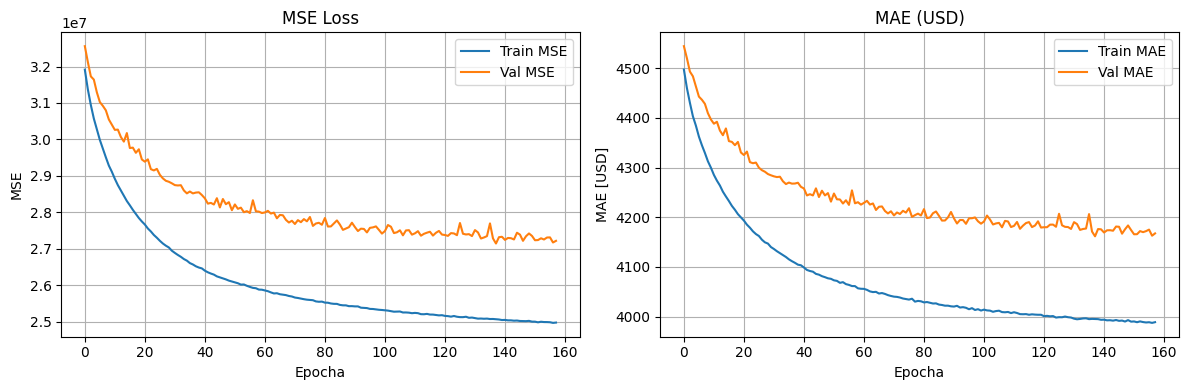

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train MSE")
axes[0].plot(history["val_loss"],   label="Val MSE")
axes[0].set_title("MSE Loss")
axes[0].set_xlabel("Epocha")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history["train_mae"], label="Train MAE")
axes[1].plot(history["val_mae"],   label="Val MAE")
axes[1].set_title("MAE (USD)")
axes[1].set_xlabel("Epocha")
axes[1].set_ylabel("MAE [USD]")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 9. Vyhodnotenie na testovacej množine

Test set model **nikdy nevidel** počas trénovania — dáva reálny odhad výkonu na nových dátach.

Vizualizácie:
- **Scatter plot** predikcia vs. skutočnosť — body blízko diagonály = dobrý model
- **Histogram reziduálov** — rozdelenie chýb by malo byť symetrické okolo 0

In [ ]:
# TODO: Spusti run_epoch pre test loader (training=False) a vypíš test MAE
test_loss, test_mae = run_epoch(test_loader, training=False)
print(f"Test MSE: {test_loss:,.1f}")
print(f"Test MAE: {test_mae:,.1f} USD")

In [ ]:
model.eval()
all_preds  = []
all_actual = []

with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b = X_b.to(device)
        preds = model(X_b).cpu().numpy()
        all_preds.append(preds)
        all_actual.append(y_b.numpy())

all_preds  = np.concatenate(all_preds).flatten()
all_actual = np.concatenate(all_actual).flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
axes[0].scatter(all_actual, all_preds, alpha=0.4, s=15)
mn = min(all_actual.min(), all_preds.min())
mx = max(all_actual.max(), all_preds.max())
axes[0].plot([mn, mx], [mn, mx], "r--", label="Ideálna predikcia")
axes[0].set_xlabel("Skutočný plat [USD]")
axes[0].set_ylabel("Predikovaný plat [USD]")
axes[0].set_title("Predikcia vs. Skutočnosť")
axes[0].legend()
axes[0].grid(True)

# Histogram reziduálov
residuals = all_preds - all_actual
axes[1].hist(residuals, bins=40, edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", label="Nulová chyba")
axes[1].set_xlabel("Reziduál (predikcia − skutočnosť) [USD]")
axes[1].set_ylabel("Počet vzoriek")
axes[1].set_title("Distribúcia chýb")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Bonusové úlohy (voliteľné)

1. **Dropout:** Pridaj `nn.Dropout(0.3)` po každej ReLU vrstve. Pomôže to? Zmeň sa val MAE?
2. **Hlbšia sieť:** Vyskúšaj architektúru `input → 256 → 128 → 64 → 1`. Čo sa zmení?
3. **Iný optimizer:** Nahraď Adam za SGD s learning rate 0.01. Porovnaj rýchlosť konvergencie.
4. **Normalizácia targetu:** Štandardizuj aj `y` (plat). Pomôže to trénovaniu?
5. **Feature importance:** Nastav všetky hodnoty jedného feature na 0 a sleduj zmenu MAE — ktorý feature je najdôležitejší?